<a href="https://colab.research.google.com/github/ShadenAhmed/DataScience-Project/blob/main/DateScience_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Collecting Data
###Phase 1

In [ ]:
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [ ]:

gold_symbol = "GC=F"
start_date = "2020-01-01"
end_date = "2026-1-31"

gold_raw_data = yf.download(gold_symbol, start=start_date, end=end_date)

print(gold_raw_data.head()) # first five days of 2020
print(gold_raw_data.tail()) # last available days in 2026

gold_raw_data.to_csv("gold_prices_2020-2026_raw.csv")


/tmp/ipython-input-1443/1211144814.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold_raw_data = yf.download(gold_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker             GC=F         GC=F         GC=F         GC=F   GC=F
Date                                                                 
2020-01-02  1524.500000  1528.699951  1518.000000  1518.099976    214
2020-01-03  1549.199951  1552.699951  1530.099976  1530.099976    107
2020-01-06  1566.199951  1580.000000  1560.400024  1580.000000    416
2020-01-07  1571.800049  1576.300049  1558.300049  1558.300049     47
2020-01-08  1557.400024  1604.199951  1552.300049  1579.699951    236
Price             Close         High          Low         Open  Volume
Ticker             GC=F         GC=F         GC=F         GC=F    GC=F
Date                                                                  
2026-01-26  5079.700195  5095.600098  5052.200195  5081.500000     180
2026-01-27  5079.899902  5079.899902  5079.899902  5079.899902      34
2026-01-28  5301.600098  5301.600098  5301.600098  5301.600098  112054
2026-01-29  53

In [ ]:
!pip install gnews

from gnews import GNews
import pandas as pd

google_news = GNews(language='en',
                    start_date=(2020, 1, 1),
                    end_date=(2026, 1, 31))


news_results = google_news.get_news('gold price war conflict geopolitical')

formatted_news = []
for article in news_results:
    formatted_news.append({
        'published_date': article['published date'],
        'title': article['title'],
        'description': article['description'],
        'url': article['url']
    })

df_news = pd.DataFrame(formatted_news)

print(df_news[['published_date', 'title']].head())

df_news.to_csv("raw_gnews_data.csv", index=False)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 24.1 MB/s eta 0:00:00
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6046 sha256=7125d567f38c8ae3b6acc9b47b4766f6fe597881ba5d3884ec2aa29ea8dfa501
  Stored in directory: /root/.cache/pip/wheels/03/f5/1a/23761066dac1d0e8e683e5fdb27e12de53209d05a4a37e6246
Successfully built sgmllib3k
                  published_date  \
0  Sat, 21 Jun 2025 07:00:00 GMT   
1  Wed, 29 Oct 2025 07:00:00 GMT   
2  Wed, 15 Nov 2023 08:00:00 GMT   
3  Wed, 02 Jul 2025 07:00:00 GMT   
4  Tue, 21 Nov 2023 08:00:00 GMT   

                                               title  
0  Gold prices should hit $4,000 as U.S. deficits...  
1  Geopolitics affirms gold as a key strategic as...  
2         The impact of wars on gold prices - 11Onze  
3  How Geopolitical Risk Drives Gold Prices - U.S...  
4  The price of g

#2. Data Processing and Cleaning
###Phase 2


# 2.1 Geopolitical news data

In [1]:
#imports + read

import pandas as pd
import re
import matplotlib.pyplot as plt

df = pd.read_csv("raw_gnews_data(Unstructered).csv")

##2.2 Gold prices data


In [ ]:
import pandas as pd

df = pd.read_csv("gold_prices_2020-2026_raw.csv")
#Initial Inspection
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1532 entries, 0 to 1531
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Price   1532 non-null   object
 1   Close   1531 non-null   object
 2   High    1531 non-null   object
 3   Low     1531 non-null   object
 4   Open    1531 non-null   object
 5   Volume  1531 non-null   object
dtypes: object(6)
memory usage: 71.9+ KB


,Price,Close,High,Low,Open,Volume
count,1532,1531,1531,1531,1531,1531
unique,1532,1405,1386,1388,1395,883
top,2026-01-30,1815.9000244140625,1813.5,1784.0,1794.300048828125,6
freq,1,4,4,4,4,10


In [ ]:
#Renaming Columns
df.rename(columns={'Price': 'Date'}, inplace=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
1,Date,NaN,NaN,NaN,NaN,NaN
2,2020-01-02,1524.5,1528.699951171875,1518.0,1518.0999755859375,214
3,2020-01-03,1549.199951171875,1552.699951171875,1530.0999755859375,1530.0999755859375,107
4,2020-01-06,1566.199951171875,1580.0,1560.4000244140625,1580.0,416


In [ ]:
#Removing Metadata Rows
df = df.iloc[2:].reset_index(drop=True)
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,1524.5,1528.699951171875,1518.0,1518.0999755859375,214
1,2020-01-03,1549.199951171875,1552.699951171875,1530.0999755859375,1530.0999755859375,107
2,2020-01-06,1566.199951171875,1580.0,1560.4000244140625,1580.0,416
3,2020-01-07,1571.800048828125,1576.300048828125,1558.300048828125,1558.300048828125,47
4,2020-01-08,1557.4000244140625,1604.199951171875,1552.300048828125,1579.699951171875,236


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
#Converting Data Types
numeric_cols = ['Close','High','Low','Open','Volume']
df[numeric_cols] = df[numeric_cols].astype(float)
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0


In [ ]:
#Removing Duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
#Sorting by Date
df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

In [ ]:
#Calculate daily returns
df['Daily_Return'] = df['Close'].pct_change()
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161


In [ ]:
#Compute daily volatility
df['Volatility'] = df['High'] - df['Low']
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN,10.699951
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902


In [ ]:
#Add new variable (Year) from the Date column
df['Year'] = df['Date'].dt.year
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year
0,2020-01-02,1524.500000,1528.699951,1518.000000,1518.099976,214.0,NaN,10.699951,2020
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976,2020
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976,2020
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000,2020
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902,2020


In [ ]:
#Handling Missing Values
df.isnull().sum()
df.dropna(inplace=True)
df.head()

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year
1,2020-01-03,1549.199951,1552.699951,1530.099976,1530.099976,107.0,0.016202,22.599976,2020
2,2020-01-06,1566.199951,1580.000000,1560.400024,1580.000000,416.0,0.010973,19.599976,2020
3,2020-01-07,1571.800049,1576.300049,1558.300049,1558.300049,47.0,0.003576,18.000000,2020
4,2020-01-08,1557.400024,1604.199951,1552.300049,1579.699951,236.0,-0.009161,51.899902,2020
5,2020-01-09,1551.699951,1555.699951,1543.300049,1555.699951,54.0,-0.003660,12.399902,2020


In [ ]:
#Outliers analyzing
Q1 = df['Daily_Return'].quantile(0.25)
Q3 = df['Daily_Return'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Daily_Return'] < Q1 - 1.5*IQR) |
              (df['Daily_Return'] > Q3 + 1.5*IQR)]

In [ ]:
#Saved cleaned and processed dataset
df.to_csv("gold_prices_cleaned.csv", index=False)


# 2.3 Exploratory Data Analysis (EDA)

In [ ]:
# EXPLORATORY DATA ANALYSIS - GOLD PRICES & GEOPOLITICAL EVENTS
#INTRODUCTION
#Exploratory Data Analysis (EDA) on gold price data from 2020-2026.
#The goal is to understand patterns, trends, and anomalies in gold prices before integrating
#with geopolitical news data. Key areas of investigation include:
# - Price trends over time
# - Daily returns distribution and patterns
# - Volatility analysis
# - Correlation between different market metrics
# - Identification of extreme events and anomalies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

In [ ]:
 #Set professional visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['lines.linewidth'] = 1.5

print("Libraries imported successfully")



Libraries imported successfully


In [ ]:
# Load the cleaned gold dataset
df = pd.read_csv('gold_prices_cleaned.csv')


In [ ]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
# Display basic information
print("="*60)
print("GOLD PRICES DATASET OVERVIEW")
print("="*60)
print(f"\n Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")
print(f"Time Span: {(df['Date'].max() - df['Date'].min()).days} days")
print(f"Years Covered: {sorted(df['Year'].unique())}")

print("\n" + "="*60)
print("FIRST 5 ROWS")
print("="*60)
df.head()

# %%
print("="*60)
print("DATA TYPES AND MISSING VALUES")
print("="*60)
df.info()

print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)
missing = df.isnull().sum()
print(missing[missing > 0] if any(missing > 0) else "No missing values found")

# %%
print("="*60)
print("BASIC STATISTICAL SUMMARY")
print("="*60)
df.describe()

GOLD PRICES DATASET OVERVIEW

 Dataset Shape: 1529 rows, 9 columns
Date Range: 2020-01-03 00:00:00 to 2026-01-30 00:00:00
Time Span: 2219 days
Years Covered: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

FIRST 5 ROWS
DATA TYPES AND MISSING VALUES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1529 entries, 0 to 1528
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1529 non-null   datetime64[ns]
 1   Close         1529 non-null   float64       
 2   High          1529 non-null   float64       
 3   Low           1529 non-null   float64       
 4   Open          1529 non-null   float64       
 5   Volume        1529 non-null   float64       
 6   Daily_Return  1529 non-null   float64       
 7   Volatility    1529 non-null   float64       
 8   Year          1529 non-null   int64         
dtypes: datetime64[ns](1), fl

,Date,Close,High,Low,Open,Volume,Daily_Return,Volatility,Year
count,1529,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000,1529.000000
mean,2023-01-16 00:35:47.285807616,2225.793718,2237.959778,2213.067102,2225.176914,4397.678875,0.000802,24.892676,2022.545455
min,2020-01-03 00:00:00,1477.300049,1484.000000,1452.099976,1469.300049,0.000000,-0.113662,0.000000,2020.000000
25%,2021-07-12 00:00:00,1796.400024,1804.199951,1787.300049,1794.300049,93.000000,-0.004400,10.700073,2021.000000
50%,2023-01-17 00:00:00,1922.099976,1929.400024,1913.699951,1922.599976,295.000000,0.001062,18.599854,2023.000000
75%,2024-07-25 00:00:00,2415.000000,2429.000000,2395.500000,2417.500000,811.000000,0.006822,31.599854,2024.000000
max,2026-01-30 00:00:00,5318.399902,5586.200195,5301.600098,5415.700195,251274.000000,0.059477,740.500000,2026.000000
std,NaN,701.848991,708.633551,695.037235,701.948456,22906.845108,0.011243,30.835723,1.744680


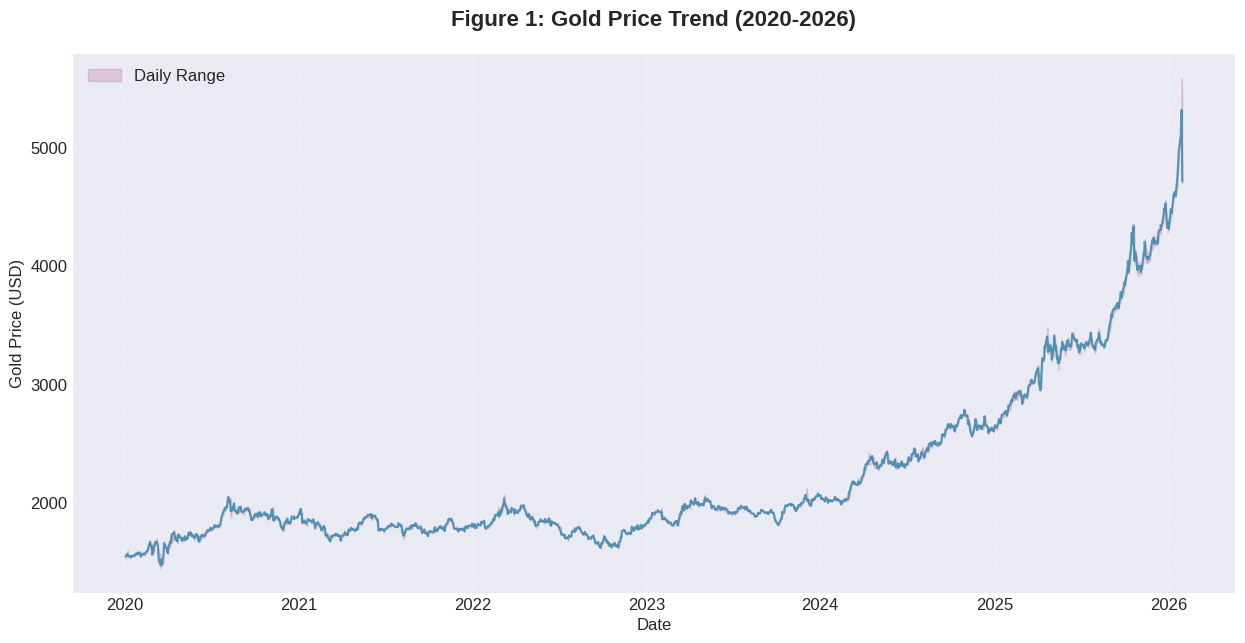

In [ ]:

#PRIMARY DATA EDA - GOLD PRICES
# FIGURE 1: Gold Price Over Time
fig, ax = plt.subplots(figsize=(15, 7))

ax.plot(df['Date'], df['Close'], color='#2E86AB', linewidth=1.5, alpha=0.8)
ax.fill_between(df['Date'], df['Low'], df['High'], alpha=0.2, color='#A23B72', label='Daily Range')
ax.set_title('Figure 1: Gold Price Trend (2020-2026)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Gold Price (USD)', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend()

In [ ]:
# Add annotations for major events (will be updated with news data)
event_dates = {
    '2020-03-11': 'COVID-19\nPandemic',
    '2022-02-24': 'Ukraine\nWar',
    '2023-10-07': 'Israel-Gaza\nConflict',
    '2024-03-01': 'Rate Cut\nExpectations'
}

for date, label in event_dates.items():
    if date in df['Date'].dt.date.astype(str).values:
        ax.axvline(x=pd.to_datetime(date), color='red', alpha=0.5, linestyle='--', linewidth=1)
        ax.text(pd.to_datetime(date), df['Close'].max()*0.9, label,
                rotation=90, fontsize=9, color='red', ha='right')

plt.tight_layout()
plt.savefig('fig1_gold_price_trend.png', dpi=300, bbox_inches='tight')
plt.show()


<Figure size 1500x800 with 0 Axes>

In [ ]:
# Calculate and display key price statistics
print("="*60)
print("KEY PRICE STATISTICS")
print("="*60)
print(f"Minimum Price: ${df['Close'].min():.2f} on {df.loc[df['Close'].idxmin(), 'Date'].strftime('%Y-%m-%d')}")
print(f"Maximum Price: ${df['Close'].max():.2f} on {df.loc[df['Close'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")
print(f"Average Price: ${df['Close'].mean():.2f}")
print(f"Median Price: ${df['Close'].median():.2f}")
print(f"Overall Price Change: {(df['Close'].iloc[-1] - df['Close'].iloc[0]):.2f} USD ({(df['Close'].iloc[-1]/df['Close'].iloc[0] - 1)*100:.1f}%)")



KEY PRICE STATISTICS
Minimum Price: $1477.30 on 2020-03-18
Maximum Price: $5318.40 on 2026-01-29
Average Price: $2225.79
Median Price: $1922.10
Overall Price Change: 3164.70 USD (204.3%)


In [ ]:
# Year-over-year analysis
print("\n" + "="*60)
print("YEARLY AVERAGE PRICES")
print("="*60)
yearly_avg = df.groupby('Year')['Close'].agg(['mean', 'min', 'max']).round(2)
print(yearly_avg)



YEARLY AVERAGE PRICES
         mean     min     max
Year                         
2020  1774.15  1477.3  2051.5
2021  1797.67  1677.7  1952.7
2022  1800.07  1623.3  2040.1
2023  1942.77  1808.8  2081.9
2024  2390.01  1990.3  2788.5
2025  3447.35  2638.4  4529.1
2026  4730.86  4314.4  5318.4


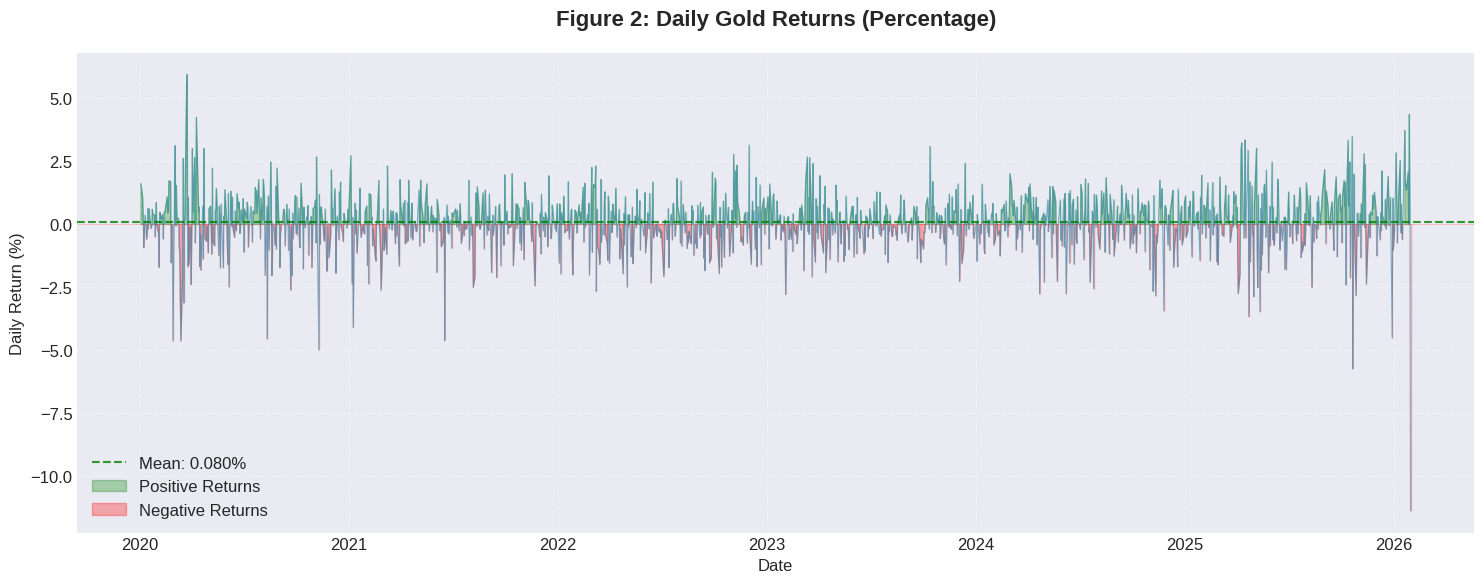

In [ ]:
# FIGURE 2: Daily Returns Over Time
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df['Date'], df['Daily_Return'] * 100, color='#2E86AB', alpha=0.6, linewidth=0.8)
ax.axhline(y=0, color='red', linestyle='-', alpha=0.3, linewidth=0.5)
ax.axhline(y=df['Daily_Return'].mean()*100, color='green', linestyle='--', alpha=0.8, label=f'Mean: {df["Daily_Return"].mean()*100:.3f}%')
ax.fill_between(df['Date'], 0, df['Daily_Return']*100, where=(df['Daily_Return']*100 > 0), color='green', alpha=0.3, label='Positive Returns')
ax.fill_between(df['Date'], 0, df['Daily_Return']*100, where=(df['Daily_Return']*100 < 0), color='red', alpha=0.3, label='Negative Returns')

ax.set_title('Figure 2: Daily Gold Returns (Percentage)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Daily Return (%)', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend()

plt.tight_layout()
plt.savefig('fig2_daily_returns.png', dpi=300, bbox_inches='tight')
plt.show()

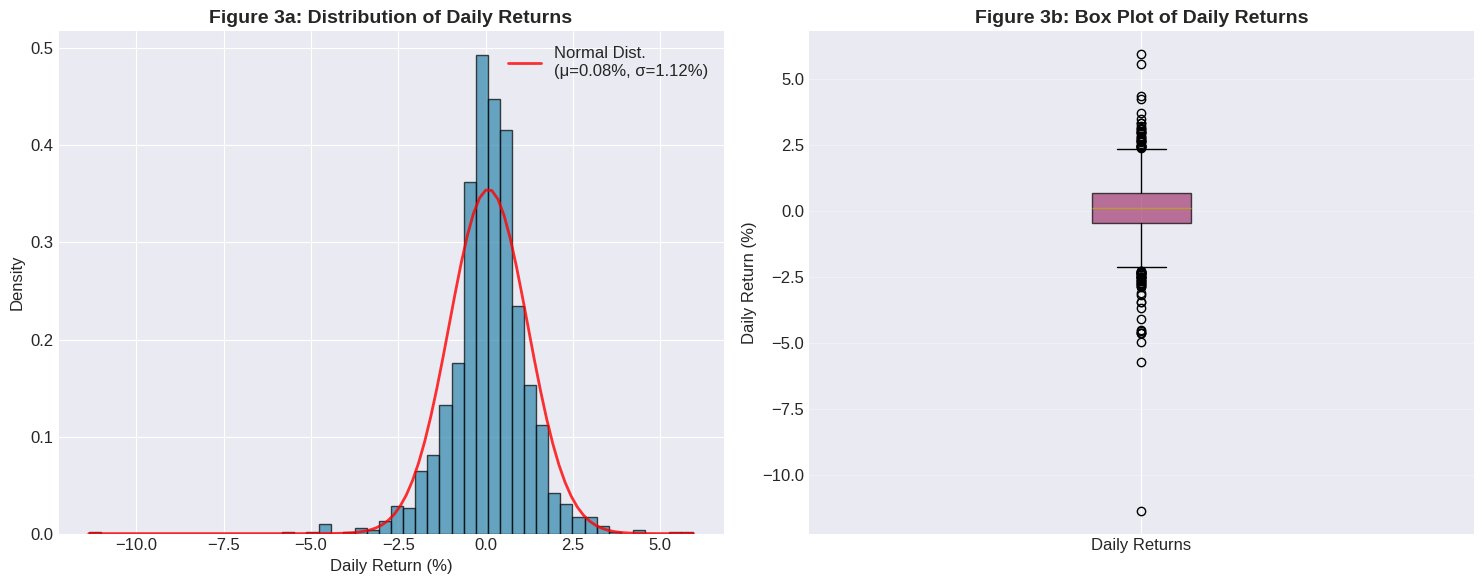

Figure 3 created successfully!
Data shape: (1529,)
Returns range: -11.37% to 5.95%
Number of valid returns: 1529


In [ ]:
# FIGURE 3: Distribution of Daily Returns (CORRECTED)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram with KDE - FIRST SUBPLOT (index 0)
axes[0].hist(df['Daily_Return']*100, bins=50, density=True, alpha=0.7, color='#2E86AB', edgecolor='black')
axes[0].set_title('Figure 3a: Distribution of Daily Returns', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Density')

# Add normal distribution curve for comparison
mu = df['Daily_Return'].mean() * 100
std = df['Daily_Return'].std() * 100
x = np.linspace(df['Daily_Return'].min()*100, df['Daily_Return'].max()*100, 100)
axes[0].plot(x, stats.norm.pdf(x, mu, std), 'r-', alpha=0.8, linewidth=2,
             label=f'Normal Dist.\n(μ={mu:.2f}%, σ={std:.2f}%)')
axes[0].legend()

# Box plot - SECOND SUBPLOT (index 1)
box_data = df['Daily_Return'].dropna() * 100
bp = axes[1].boxplot(box_data, vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('#A23B72')
bp['boxes'][0].set_alpha(0.7)
axes[1].set_title('Figure 3b: Box Plot of Daily Returns', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Daily Return (%)')
axes[1].set_xticklabels(['Daily Returns'])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig3_returns_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Print debug info
print(f"Figure 3 created successfully!")
print(f"Data shape: {df['Daily_Return'].shape}")
print(f"Returns range: {df['Daily_Return'].min()*100:.2f}% to {df['Daily_Return'].max()*100:.2f}%")
print(f"Number of valid returns: {df['Daily_Return'].count()}")

In [ ]:

# Calculate return statistics
print("="*60)
print("DAILY RETURNS STATISTICS")
print("="*60)
return_stats = {
    'Mean Return (%)': df['Daily_Return'].mean() * 100,
    'Median Return (%)': df['Daily_Return'].median() * 100,
    'Std Deviation (%)': df['Daily_Return'].std() * 100,
    'Skewness': skew(df['Daily_Return'].dropna()),
    'Kurtosis': kurtosis(df['Daily_Return'].dropna()),
    'Minimum Return (%)': df['Daily_Return'].min() * 100,
    'Maximum Return (%)': df['Daily_Return'].max() * 100,
    'Positive Days (%)': (df['Daily_Return'] > 0).mean() * 100,
    'Negative Days (%)': (df['Daily_Return'] < 0).mean() * 100
}

for key, value in return_stats.items():
    print(f"{key}: {value:.4f}")

# Find extreme returns
print("\n" + "="*60)
print("EXTREME DAILY RETURNS (>|5%|)")
print("="*60)
extreme_returns = df[abs(df['Daily_Return']*100) > 5][['Date', 'Close', 'Daily_Return']].copy()
extreme_returns['Daily_Return_%'] = extreme_returns['Daily_Return'] * 100
print(extreme_returns.to_string(index=False))

DAILY RETURNS STATISTICS
Mean Return (%): 0.0802
Median Return (%): 0.1062
Std Deviation (%): 1.1243
Skewness: -0.8974
Kurtosis: 9.5300
Minimum Return (%): -11.3662
Maximum Return (%): 5.9477
Positive Days (%): 55.6573
Negative Days (%): 44.1465

EXTREME DAILY RETURNS (>|5%|)
      Date       Close  Daily_Return  Daily_Return_%
2020-03-23 1567.000000      0.055930        5.592992
2020-03-24 1660.199951      0.059477        5.947668
2025-10-21 4087.699951     -0.057352       -5.735171
2026-01-30 4713.899902     -0.113662      -11.366201


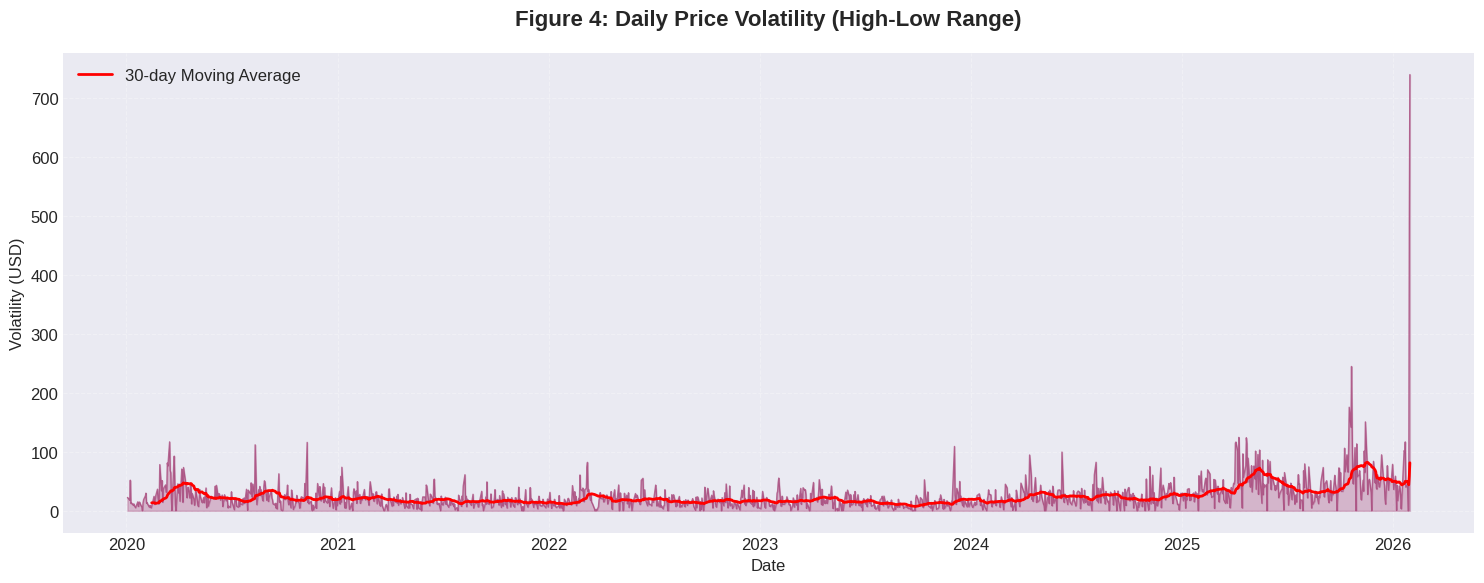

In [ ]:

# FIGURE 4: Volatility Over Time
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(df['Date'], df['Volatility'], color='#A23B72', linewidth=1, alpha=0.7)
ax.fill_between(df['Date'], 0, df['Volatility'], alpha=0.3, color='#A23B72')
ax.set_title('Figure 4: Daily Price Volatility (High-Low Range)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volatility (USD)', fontsize=12)
ax.grid(True, alpha=0.3, linestyle='--')

# Add rolling average for trend
rolling_vol = df['Volatility'].rolling(window=30).mean()
ax.plot(df['Date'], rolling_vol, color='red', linewidth=2, label='30-day Moving Average')
ax.legend()

plt.tight_layout()
plt.savefig('fig4_volatility_trend.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:

# Identify high volatility periods
print("="*60)
print("VOLATILITY STATISTICS")
print("="*60)
print(f"Average Daily Volatility: ${df['Volatility'].mean():.2f}")
print(f"Maximum Volatility: ${df['Volatility'].max():.2f} on {df.loc[df['Volatility'].idxmax(), 'Date'].strftime('%Y-%m-%d')}")
print(f"Minimum Volatility: ${df['Volatility'].min():.2f}")

print("\n" + "="*60)
print("TOP 10 HIGHEST VOLATILITY DAYS")
print("="*60)
top_volatility = df.nlargest(10, 'Volatility')[['Date', 'Close', 'Volatility', 'Daily_Return']]
top_volatility['Daily_Return_%'] = top_volatility['Daily_Return'] * 100
print(top_volatility.to_string(index=False))

VOLATILITY STATISTICS
Average Daily Volatility: $24.89
Maximum Volatility: $740.50 on 2026-01-30
Minimum Volatility: $0.00

TOP 10 HIGHEST VOLATILITY DAYS
      Date       Close  Volatility  Daily_Return  Daily_Return_%
2026-01-30 4713.899902  740.500000     -0.113662      -11.366201
2026-01-29 5318.399902  488.700195      0.003169        0.316882
2025-10-21 4087.699951  245.000244     -0.057352       -5.735171
2025-10-17 4189.899902  175.799805     -0.021097       -2.109721
2025-11-14 4087.600098  150.899902     -0.023717       -2.371678
2025-10-22 4044.399902  142.500000     -0.010593       -1.059277
2025-10-20 4336.399902  142.000000      0.034965        3.496504
2025-04-09 3056.500000  124.599854      0.029679        2.967932
2025-04-22 3400.800049  123.900146     -0.001585       -0.158532
2020-03-16 1485.900024  117.000000     -0.019661       -1.966084


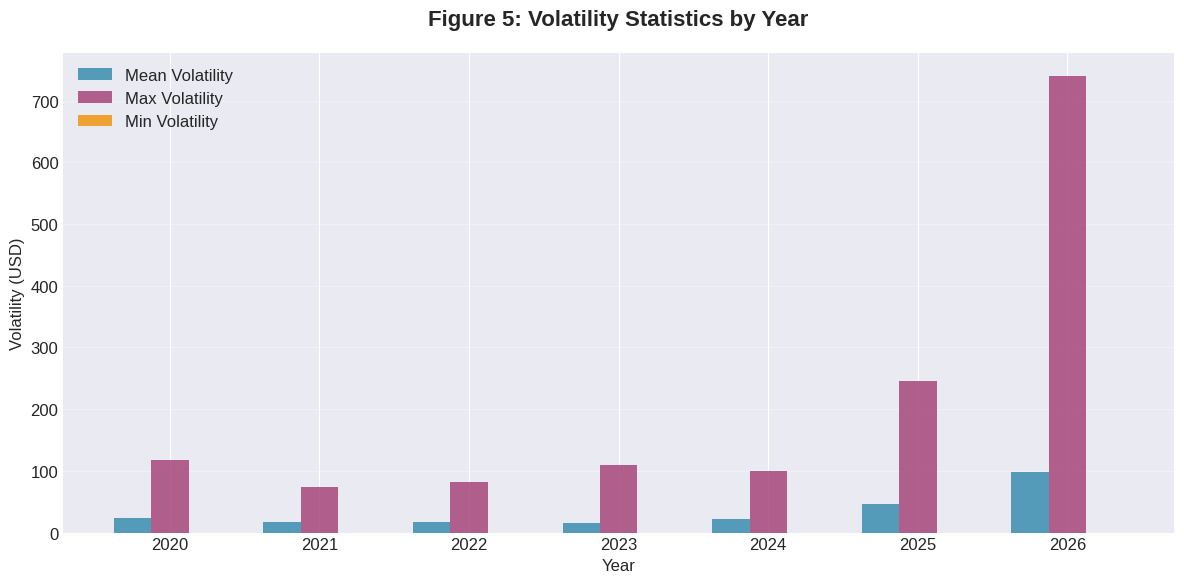

In [ ]:

# FIGURE 5: Volatility by Year
fig, ax = plt.subplots(figsize=(12, 6))

yearly_vol = df.groupby('Year')['Volatility'].agg(['mean', 'max', 'min']).reset_index()
x = np.arange(len(yearly_vol['Year']))
width = 0.25

ax.bar(x - width, yearly_vol['mean'], width, label='Mean Volatility', color='#2E86AB', alpha=0.8)
ax.bar(x, yearly_vol['max'], width, label='Max Volatility', color='#A23B72', alpha=0.8)
ax.bar(x + width, yearly_vol['min'], width, label='Min Volatility', color='#F18F01', alpha=0.8)

ax.set_title('Figure 5: Volatility Statistics by Year', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Volatility (USD)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(yearly_vol['Year'])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig5_volatility_by_year.png', dpi=300, bbox_inches='tight')
plt.show()

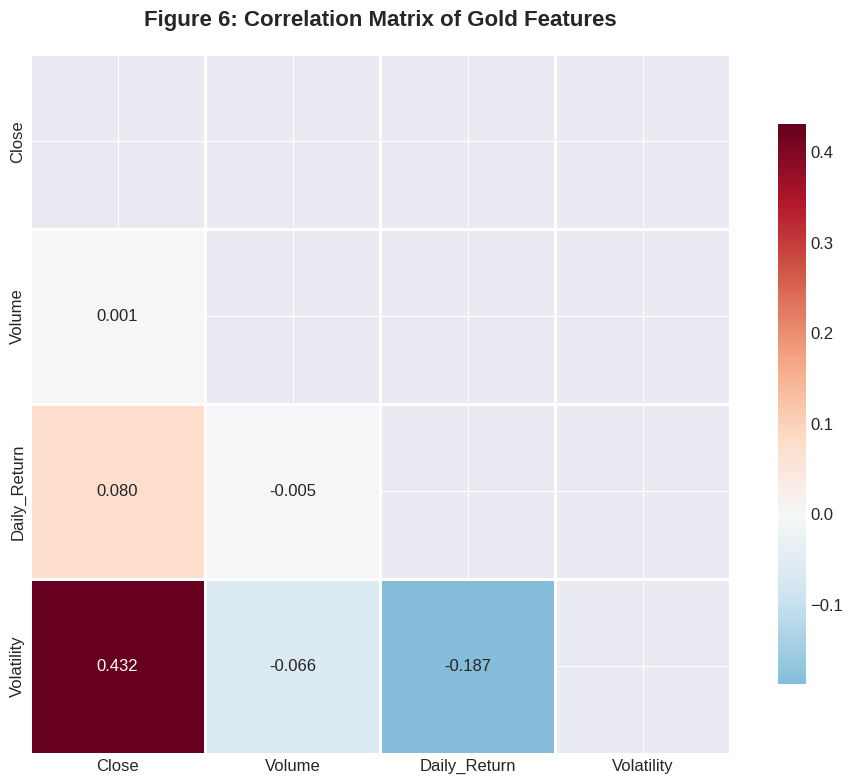

In [ ]:

# FIGURE 6: Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 8))

# Select numerical columns for correlation
corr_cols = ['Close', 'Volume', 'Daily_Return', 'Volatility']
corr_matrix = df[corr_cols].corr()

# Create heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, mask=mask,
            annot_kws={'size': 12}, ax=ax)

ax.set_title('Figure 6: Correlation Matrix of Gold Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig6_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Correlation statistics
print("="*60)
print("CORRELATION ANALYSIS")
print("="*60)
print("Strongest Correlations:")
print(f"• Close vs Volatility: {corr_matrix.loc['Close', 'Volatility']:.3f}")
print(f"• Close vs Volume: {corr_matrix.loc['Close', 'Volume']:.3f}")
print(f"• Daily Return vs Volatility: {corr_matrix.loc['Daily_Return', 'Volatility']:.3f}")
print(f"• Volume vs Volatility: {corr_matrix.loc['Volume', 'Volatility']:.3f}")

CORRELATION ANALYSIS
Strongest Correlations:
• Close vs Volatility: 0.432
• Close vs Volume: 0.001
• Daily Return vs Volatility: -0.187
• Volume vs Volatility: -0.066


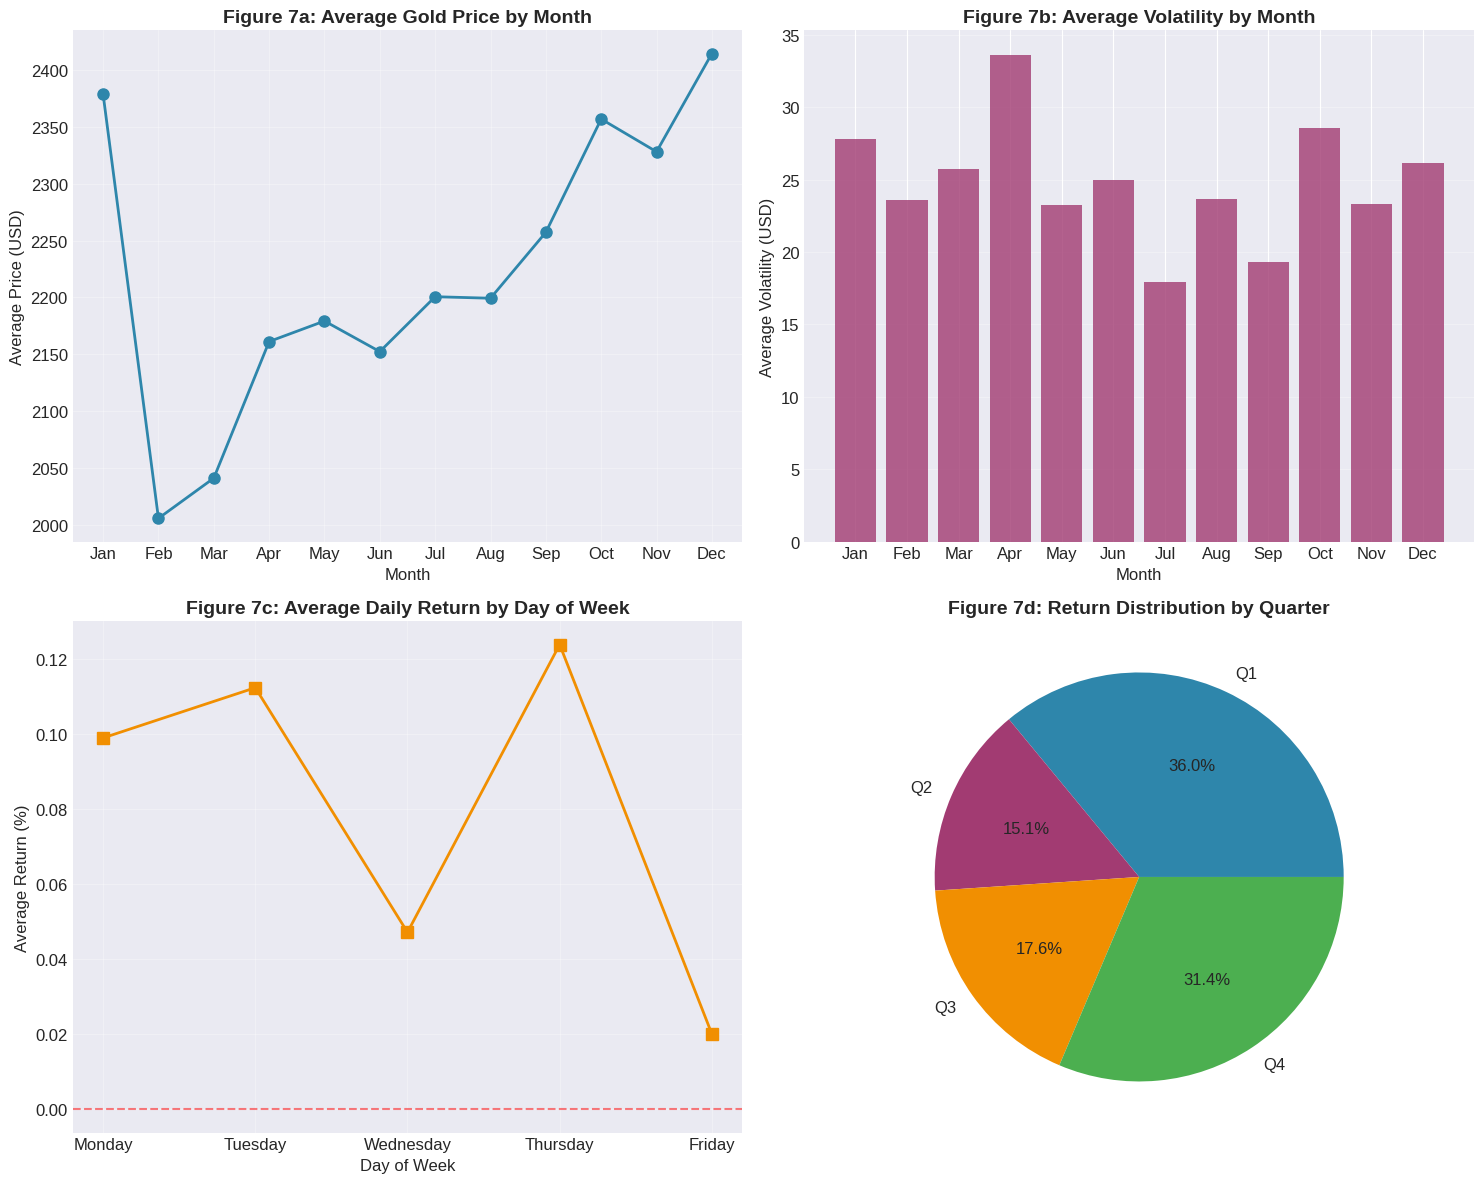

In [ ]:

# FIGURE 7: Monthly Patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Monthly average prices
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Close'].mean()

axes[0,0].plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2, markersize=8, color='#2E86AB')
axes[0,0].set_title('Figure 7a: Average Gold Price by Month', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Average Price (USD)')
axes[0,0].set_xticks(range(1,13))
axes[0,0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0,0].grid(True, alpha=0.3)

# Monthly volatility
monthly_vol = df.groupby('Month')['Volatility'].mean()
axes[0,1].bar(monthly_vol.index, monthly_vol.values, color='#A23B72', alpha=0.8)
axes[0,1].set_title('Figure 7b: Average Volatility by Month', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Month')
axes[0,1].set_ylabel('Average Volatility (USD)')
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0,1].grid(True, alpha=0.3, axis='y')

# Day of week patterns (if we had day of week)
df['DayOfWeek'] = df['Date'].dt.day_name()
dow_avg = df.groupby('DayOfWeek')['Daily_Return'].mean() * 100
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
dow_avg = dow_avg.reindex(dow_order)

axes[1,0].plot(range(len(dow_avg)), dow_avg.values, marker='s', linewidth=2, markersize=8, color='#F18F01')
axes[1,0].set_title('Figure 7c: Average Daily Return by Day of Week', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Day of Week')
axes[1,0].set_ylabel('Average Return (%)')
axes[1,0].set_xticks(range(len(dow_avg)))
axes[1,0].set_xticklabels(dow_order)
axes[1,0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1,0].grid(True, alpha=0.3)

# Quarterly patterns
df['Quarter'] = df['Date'].dt.quarter
quarterly_ret = df.groupby('Quarter')['Daily_Return'].mean() * 100
axes[1,1].pie(quarterly_ret.values, labels=[f'Q{q}' for q in quarterly_ret.index],
              autopct='%1.1f%%', colors=['#2E86AB', '#A23B72', '#F18F01', '#4CAF50'])
axes[1,1].set_title('Figure 7d: Return Distribution by Quarter', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('fig7_time_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

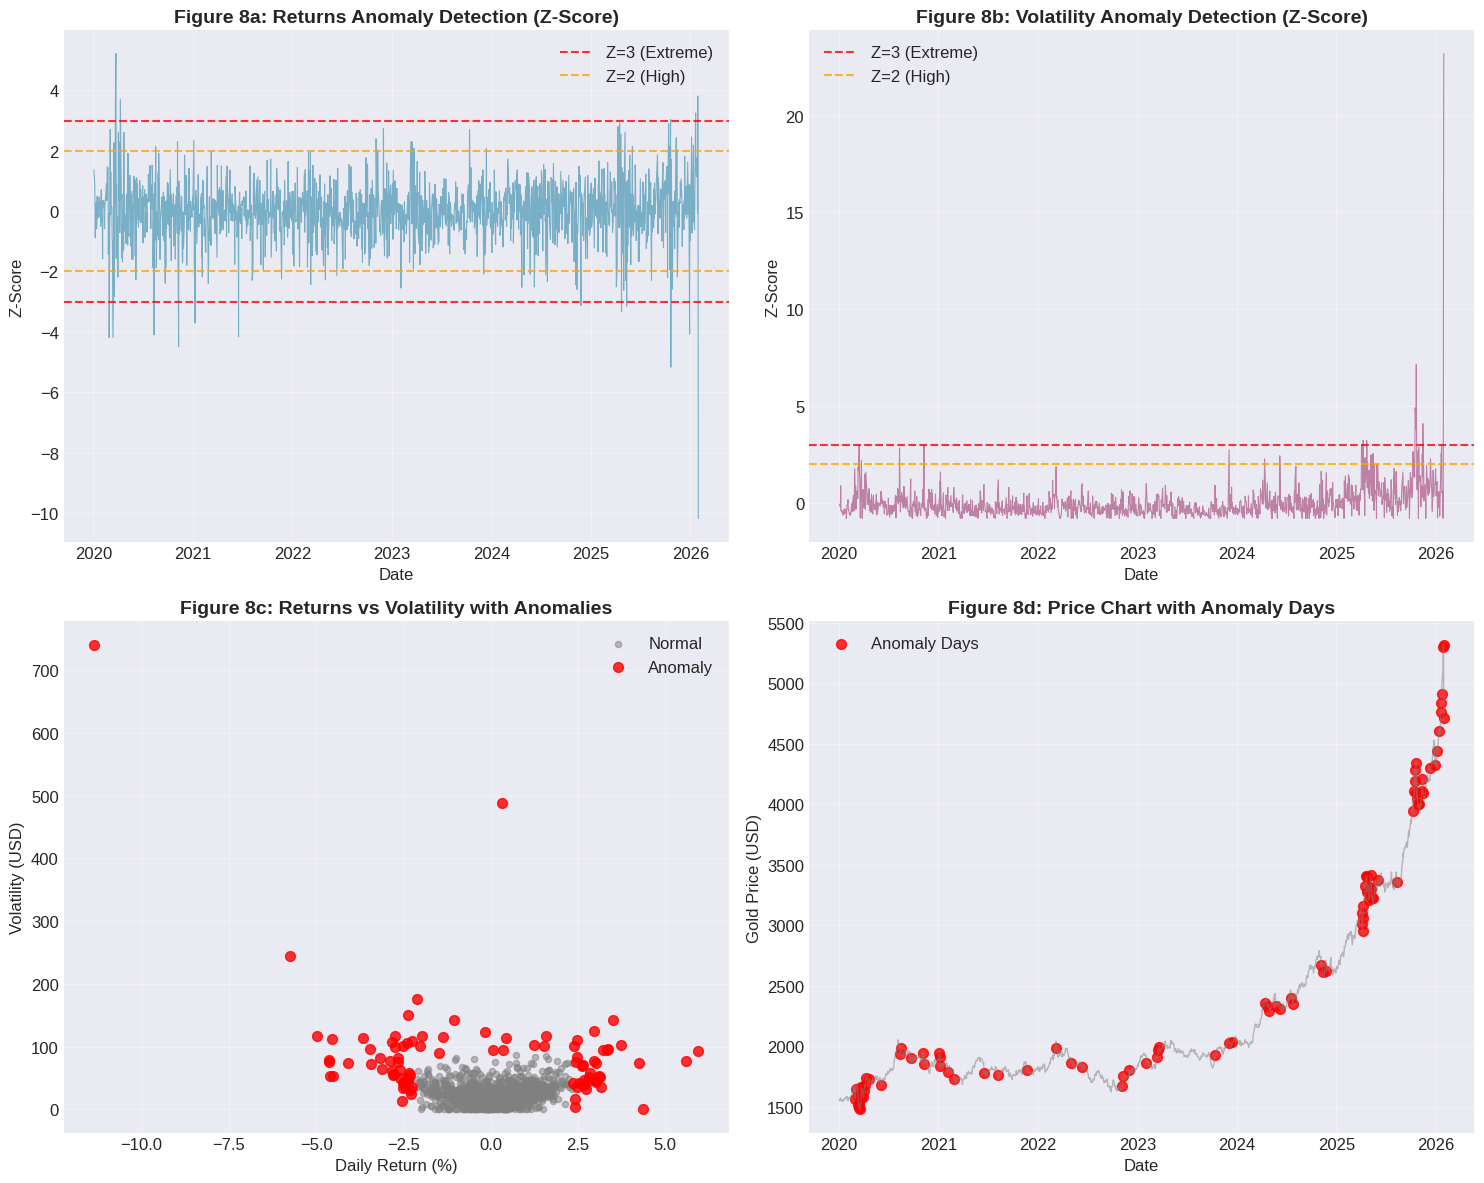

In [ ]:

# FIGURE 8: Anomaly Detection Using Z-Score
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Calculate z-scores
df['Return_Zscore'] = (df['Daily_Return'] - df['Daily_Return'].mean()) / df['Daily_Return'].std()
df['Volatility_Zscore'] = (df['Volatility'] - df['Volatility'].mean()) / df['Volatility'].std()

# Plot 1: Returns Z-scores
axes[0,0].plot(df['Date'], df['Return_Zscore'], color='#2E86AB', alpha=0.6, linewidth=0.8)
axes[0,0].axhline(y=3, color='red', linestyle='--', alpha=0.8, label='Z=3 (Extreme)')
axes[0,0].axhline(y=-3, color='red', linestyle='--', alpha=0.8)
axes[0,0].axhline(y=2, color='orange', linestyle='--', alpha=0.8, label='Z=2 (High)')
axes[0,0].axhline(y=-2, color='orange', linestyle='--', alpha=0.8)
axes[0,0].set_title('Figure 8a: Returns Anomaly Detection (Z-Score)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Z-Score')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Volatility Z-scores
axes[0,1].plot(df['Date'], df['Volatility_Zscore'], color='#A23B72', alpha=0.6, linewidth=0.8)
axes[0,1].axhline(y=3, color='red', linestyle='--', alpha=0.8, label='Z=3 (Extreme)')
axes[0,1].axhline(y=2, color='orange', linestyle='--', alpha=0.8, label='Z=2 (High)')
axes[0,1].set_title('Figure 8b: Volatility Anomaly Detection (Z-Score)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Z-Score')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Scatter plot with anomaly highlighting
anomalies = df[(abs(df['Return_Zscore']) > 2) | (df['Volatility_Zscore'] > 2)]
normal = df[~((abs(df['Return_Zscore']) > 2) | (df['Volatility_Zscore'] > 2))]

axes[1,0].scatter(normal['Daily_Return']*100, normal['Volatility'], alpha=0.5, s=20, color='gray', label='Normal')
axes[1,0].scatter(anomalies['Daily_Return']*100, anomalies['Volatility'], alpha=0.8, s=50, color='red', label='Anomaly')
axes[1,0].set_title('Figure 8c: Returns vs Volatility with Anomalies', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Daily Return (%)')
axes[1,0].set_ylabel('Volatility (USD)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Time series with anomaly highlighting
axes[1,1].plot(df['Date'], df['Close'], color='gray', alpha=0.5, linewidth=1)
axes[1,1].scatter(anomalies['Date'], anomalies['Close'], color='red', s=50, alpha=0.8, label='Anomaly Days')
axes[1,1].set_title('Figure 8d: Price Chart with Anomaly Days', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Gold Price (USD)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig8_anomaly_detection.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Anomoly Statistics
print("="*60)
print("ANOMALY DETECTION RESULTS")
print("="*60)
print(f"Total anomalies detected: {len(anomalies)}")
print(f"Percentage of days: {(len(anomalies)/len(df))*100:.2f}%")

print("\n" + "="*60)
print("TOP 10 MOST EXTREME ANOMALY DAYS")
print("="*60)
top_anomalies = anomalies.nlargest(10, 'Volatility_Zscore')[['Date', 'Close', 'Daily_Return', 'Volatility', 'Return_Zscore', 'Volatility_Zscore']]
top_anomalies['Daily_Return_%'] = top_anomalies['Daily_Return'] * 100
print(top_anomalies.to_string(index=False))

ANOMALY DETECTION RESULTS
Total anomalies detected: 91
Percentage of days: 5.95%

TOP 10 MOST EXTREME ANOMALY DAYS
      Date       Close  Daily_Return  Volatility  Return_Zscore  Volatility_Zscore  Daily_Return_%
2026-01-30 4713.899902     -0.113662  740.500000     -10.181049          23.207088      -11.366201
2026-01-29 5318.399902      0.003169  488.700195       0.210504          15.041241        0.316882
2025-10-21 4087.699951     -0.057352  245.000244      -5.172513           7.138071       -5.735171
2025-10-17 4189.899902     -0.021097  175.799805      -1.947845           4.893906       -2.109721
2025-11-14 4087.600098     -0.023717  150.899902      -2.180844           4.086404       -2.371678
2025-10-22 4044.399902     -0.010593  142.500000      -1.013524           3.813996       -1.059277
2025-10-20 4336.399902      0.034965  142.000000       3.038628           3.797781        3.496504
2025-04-09 3056.500000      0.029679  124.599854       2.568489           3.233496        2.9